# DXA prototype: классификация, геометрические проверки и сегментация

Ноутбук реализует только пункты, которые уже описаны в заметках:

1. Фильтрация фона по порогу.
2. Классификатор `LEG / SPINE`: предобученный ResNet + классификационная голова.
3. Бедро:
   - металл — отдельный ResNet-классификатор;
   - позиционирование — три геометрические проверки с перебором углов;
   - ротация ("горбик") — анализ локального излома контура.
4. Позвоночник:
   - угол — профиль яркости, межпозвонковые разделения, перебор углов и оси симметрии;
   - позиция — сегментация подвздошных костей и доля их площади.

**Пока не реализуем** раздел `3.3. Проблемы`, потому что способ в заметках ещё не определён.

Также пока не вводим окончательные медицинские пороги и не сворачиваем проверки в единый `quality=0/1`: сначала их нужно откалибровать на размеченной выборке.

## 0. Установка библиотек

Для Windows/Jupyter можно выполнить следующую ячейку. Если PyTorch с CUDA уже установлен отдельно, уберите `torch torchvision` из команды.

In [1]:
%pip install -q pydicom pylibjpeg pylibjpeg-libjpeg numpy pandas matplotlib ipympl scipy scikit-image scikit-learn opencv-python-headless pillow tqdm torch torchvision segmentation-models-pytorch

Note: you may need to restart the kernel to use updated packages.


## 1. Импорты и конфигурация

In [2]:
%matplotlib widget

from pathlib import Path, PurePosixPath
from contextlib import nullcontext
from collections import defaultdict
import math
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import pydicom
try:
    from pydicom.pixels import apply_modality_lut, apply_voi_lut
except ImportError:
    from pydicom.pixel_data_handlers.util import apply_modality_lut, apply_voi_lut

from scipy.ndimage import gaussian_filter1d, rotate as ndi_rotate
from scipy.signal import find_peaks, savgol_filter
from skimage.filters import threshold_otsu
from skimage.morphology import (
    remove_small_objects, remove_small_holes,
    binary_closing, disk, skeletonize
)
from skimage.measure import label as cc_label, regionprops

from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score, roc_auc_score
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import resnet18, ResNet18_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [3]:
# === Пути ===
DATASET_ROOT = Path(r"C:\Users\Андрей\Desktop\Хакатон")
STUDIES_ROOT = DATASET_ROOT / "Исследования"
DEFAULT_LABELS_CSV = DATASET_ROOT / "Размеченные" / "labels.csv"
LABEL_GLOB = "Размеченные*/labels.csv"

METAL_LABELS_CSV = DATASET_ROOT / "metal_labels.csv"
ILIAC_MASKS_CSV = DATASET_ROOT / "iliac_masks.csv"

WORK_DIR = DATASET_ROOT / "prototype_output"
WORK_DIR.mkdir(parents=True, exist_ok=True)

# === Предобработка ===
# Мягкий порог: зануляем только нижний 1% НЕНУЛЕВЫХ значений.
BACKGROUND_METHOD = "quantile_positive"
BACKGROUND_QUANTILE = 0.01

# === Обучение ===
IMAGE_SIZE = 224
BATCH_SIZE = 16
HEAD_EPOCHS = 3
FINETUNE_EPOCHS = 5
NUM_WORKERS = 0

# === Бедро: три ручные точки и ширина по наклонной линии ===
# Угол задаётся ОТ ВЕРТИКАЛИ:
# 0° = вертикальная линия, + угол наклоняется вправо книзу.
HIP_LINE_ANGLES_FROM_VERTICAL = {
    "1": -30.0,
    "2":  45.0,
    "3": -30.0,
}

# Вокруг выбранной пользователем точки перебираем ПАРАЛЛЕЛЬНЫЕ линии,
# смещаясь перпендикулярно им.
HIP_OFFSET_SEARCH_PX = 45

# Полудлина линии, на которой считаем количество ненулевых пикселей.
HIP_LINE_HALF_LENGTH_PX = 160

# Нулевые и совсем короткие случайные фрагменты не считаем "узким местом".
HIP_MIN_NONZERO_PIXELS = 5

# === Горбик ===
# Для горбика порог НЕ применяется.
BUMP_ROI_HALF_WIDTH = 90
BUMP_ROI_HALF_HEIGHT = 120
BUMP_EDGE_CONTINUITY_PX = 20

# === Позвоночник ===
# 7 структур: T12, L1, L2, L3, L4, L5, крестец -> 6 границ.
SPINE_N_SEPARATORS = 6

# Между выбранными границами должно быть минимум H/8.
SPINE_MIN_DISTANCE_DIVISOR = 8

SPINE_SEPARATOR_ANGLE_RANGE = (-16, 16)
SPINE_SEPARATOR_ANGLE_STEP = 2
SPINE_EDGE_MARGIN_FRAC = 0.03

SPINE_SEGMENT_NAMES = [
    "T12", "L1", "L2", "L3", "L4", "L5", "SACRUM"
]

print("STUDIES_ROOT:", STUDIES_ROOT)
print("WORK_DIR:", WORK_DIR)

STUDIES_ROOT: C:\Users\Андрей\Desktop\Хакатон\Исследования
WORK_DIR: C:\Users\Андрей\Desktop\Хакатон\prototype_output


## 2. Чтение DICOM и отсечение фона

Используем `RescaleSlope/Intercept`, VOI LUT, учитываем `MONOCHROME1`, затем нормализуем изображение в `[0, 1]`.

После этого всё ниже порога переводится в 0. Для прототипа порог определяется Otsu и масштабируется `BACKGROUND_THRESHOLD_SCALE`.

In [4]:
def read_dicom_float(path):
    ds = pydicom.dcmread(path, force=True)
    arr = ds.pixel_array

    if arr.ndim > 2:
        arr = arr[0]

    arr = arr.astype(np.float32)

    try:
        arr = apply_modality_lut(arr, ds).astype(np.float32)
    except Exception:
        slope = float(getattr(ds, "RescaleSlope", 1.0))
        intercept = float(getattr(ds, "RescaleIntercept", 0.0))
        arr = arr * slope + intercept

    try:
        arr = apply_voi_lut(arr, ds).astype(np.float32)
    except Exception:
        pass

    if str(getattr(ds, "PhotometricInterpretation", "")) == "MONOCHROME1":
        arr = np.nanmax(arr) - arr

    return ds, arr


def robust_normalize(arr, low=0.5, high=99.5):
    arr = np.asarray(arr, dtype=np.float32)
    finite = np.isfinite(arr)

    if not finite.any():
        return np.zeros_like(arr, dtype=np.float32)

    lo = np.percentile(arr[finite], low)
    hi = np.percentile(arr[finite], high)

    if hi <= lo:
        lo = np.min(arr[finite])
        hi = np.max(arr[finite])

    if hi <= lo:
        return np.zeros_like(arr, dtype=np.float32)

    return np.clip((arr - lo) / (hi - lo), 0, 1).astype(np.float32)


def black_background(img01, method="quantile_positive", quantile=0.01):
    """
    Для DXA здесь намеренно используем мягкую фильтрацию:
    зануляем только самый тёмный хвост распределения.
    Это лучше сохраняет кость, чем Otsu на всём изображении.
    """
    img = np.asarray(img01, dtype=np.float32)
    positive = img[np.isfinite(img) & (img > 0)]

    if len(positive) == 0:
        return img.copy(), 0.0

    if method == "quantile_positive":
        threshold = float(np.quantile(positive, quantile))
    elif method == "otsu_positive":
        try:
            threshold = float(threshold_otsu(positive))
        except Exception:
            threshold = float(np.quantile(positive, quantile))
    elif method == "quantile_all":
        finite = img[np.isfinite(img)]
        threshold = float(np.quantile(finite, quantile))
    else:
        threshold = float(method)

    out = img.copy()
    out[out < threshold] = 0.0
    return out, threshold


def preprocess_dicom(path):
    ds, raw = read_dicom_float(Path(path))
    norm = robust_normalize(raw)
    filtered, threshold = black_background(
        norm,
        method=BACKGROUND_METHOD,
        quantile=BACKGROUND_QUANTILE,
    )
    return ds, raw, norm, filtered, threshold


def show_preprocessing(path):
    ds, raw, norm, filtered, threshold = preprocess_dicom(path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title("Исходный DICOM")
    axes[0].axis("off")

    axes[1].imshow(norm, cmap="gray")
    axes[1].set_title("Нормализация")
    axes[1].axis("off")

    axes[2].imshow(filtered, cmap="gray")
    axes[2].set_title(
        f"Фон → 0; {BACKGROUND_METHOD}, q={BACKGROUND_QUANTILE:.2%}, "
        f"thr={threshold:.3f}"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Найдено DICOM: 499
C:\Users\Андрей\Desktop\Хакатон\Исследования\1.2.840.113619.2.110.512719.20250403090444\series_004_3_CR\DXA\CR DXA\CR000000.dcm


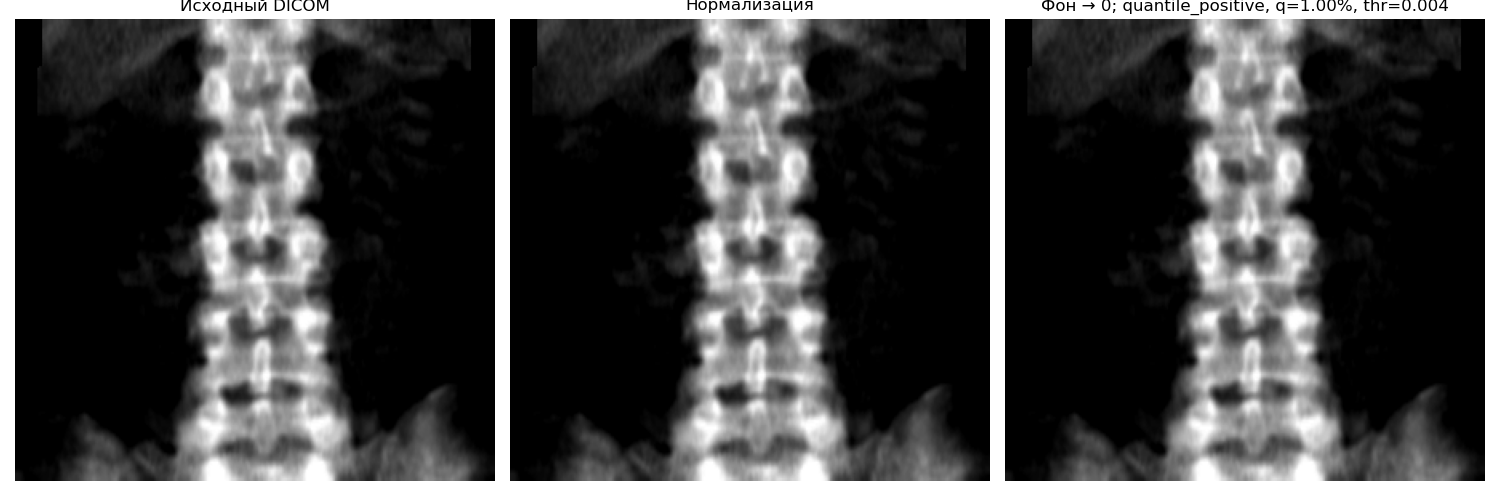

C:\Users\Андрей\Desktop\Хакатон\Исследования\1.2.840.113619.2.110.512719.20250403090444\series_004_3_CR\DXA\CR DXA\CR000001.dcm


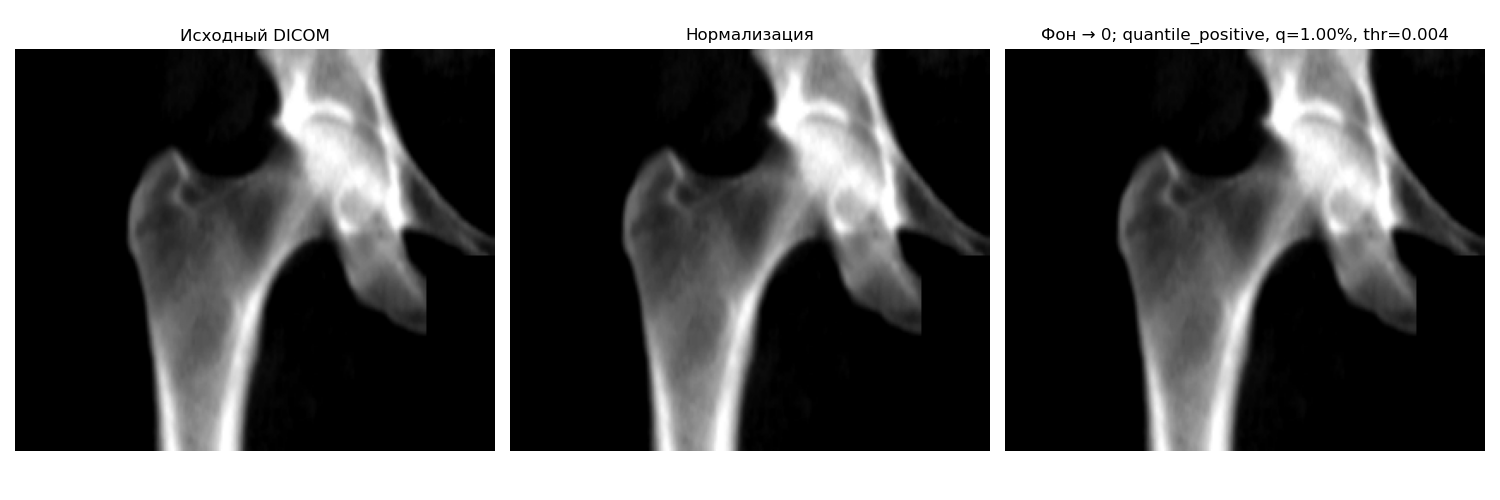

C:\Users\Андрей\Desktop\Хакатон\Исследования\1.2.840.113619.2.110.512719.20250403090444\series_004_3_CR\DXA\CR DXA\CR000002.dcm


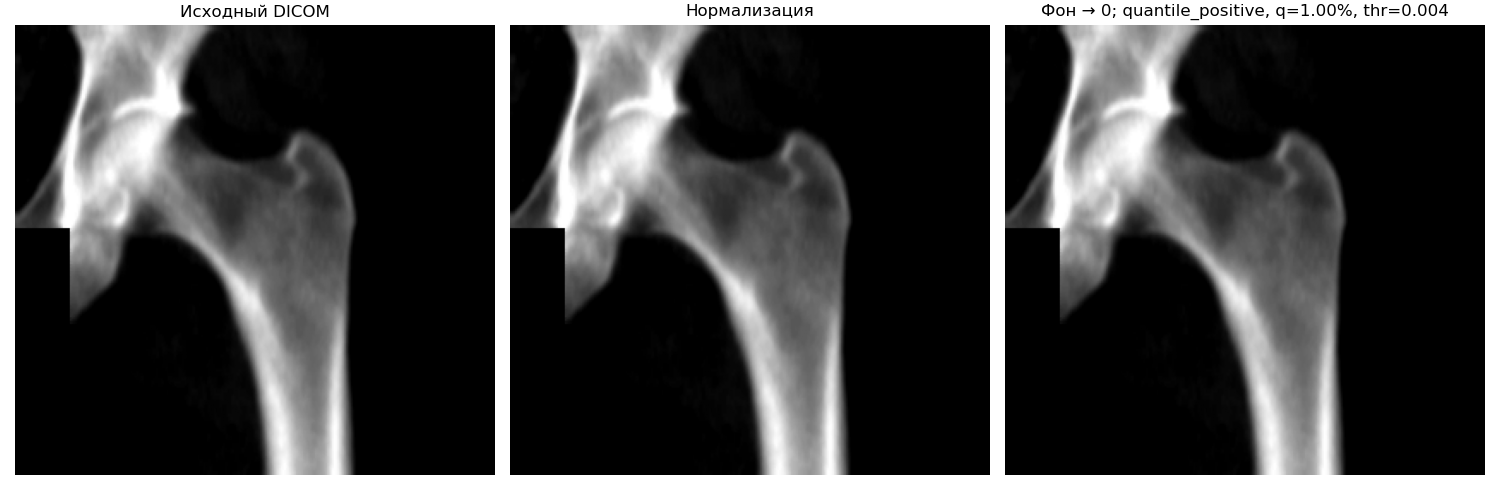

In [5]:
all_dicoms = sorted(STUDIES_ROOT.rglob("*.dcm"))
print("Найдено DICOM:", len(all_dicoms))

for path in all_dicoms[:3]:
    print(path)
    show_preprocessing(path)

## 3. Загрузка ручной разметки `LEG / SPINE`

In [6]:
def normalize_path_string(value):
    s = str(value).strip().replace("\\", "/")
    while "//" in s:
        s = s.replace("//", "/")
    return s.lstrip("./")


def path_candidates_from_label(value):
    """
    Возвращает несколько вариантов relative_path.
    Это позволяет пережить:
    - абсолютные Windows paths;
    - /data/... из Docker;
    - Исследования/...;
    - различия в количестве ведущих каталогов.
    """
    raw = normalize_path_string(value)
    candidates = [raw]

    parts = list(PurePosixPath(raw).parts)
    folded = [str(p).casefold() for p in parts]

    for anchor in ("исследования", "data"):
        if anchor in folded:
            i = folded.index(anchor)
            if i + 1 < len(parts):
                candidates.append("/".join(parts[i + 1:]))

    # Несколько suffix-вариантов.
    for n in range(2, min(7, len(parts)) + 1):
        candidates.append("/".join(parts[-n:]))

    # Убираем дубли, сохраняя порядок.
    out = []
    seen = set()
    for x in candidates:
        key = x.casefold()
        if key not in seen:
            seen.add(key)
            out.append(x)

    return out


def build_dicom_catalog(root):
    files = sorted(root.rglob("*.dcm"))

    exact = {}
    suffix = defaultdict(list)
    basename = defaultdict(list)

    rows = []

    for path in files:
        rel = normalize_path_string(path.relative_to(root))
        parts = PurePosixPath(rel).parts

        exact[rel.casefold()] = path
        basename[path.name.casefold()].append(path)

        for n in range(2, min(7, len(parts)) + 1):
            key = "/".join(parts[-n:]).casefold()
            suffix[key].append(path)

        rows.append({
            "dicom_path": path,
            "relative_path": rel,
        })

    return files, exact, suffix, basename, pd.DataFrame(rows)


ALL_DICOMS, DICOM_EXACT, DICOM_SUFFIX, DICOM_BASENAME, DICOM_CATALOG_DF = (
    build_dicom_catalog(STUDIES_ROOT)
)

print("DICOM реально найдено в STUDIES_ROOT:", len(ALL_DICOMS))


def resolve_dicom_path(relative_path):
    """
    Возвращает (Path | None, method).
    Сначала ищем точный relative_path, затем уникальный suffix,
    затем basename только если он уникален.
    """
    for candidate in path_candidates_from_label(relative_path):
        key = candidate.casefold()

        if key in DICOM_EXACT:
            return DICOM_EXACT[key], "exact"

        matches = DICOM_SUFFIX.get(key, [])
        if len(matches) == 1:
            return matches[0], "unique_suffix"

    name = PurePosixPath(
        normalize_path_string(relative_path)
    ).name.casefold()

    matches = DICOM_BASENAME.get(name, [])
    if len(matches) == 1:
        return matches[0], "unique_basename"

    return None, "not_found"


def load_all_manual_labels():
    csv_files = sorted(DATASET_ROOT.glob(LABEL_GLOB))

    if DEFAULT_LABELS_CSV.exists() and DEFAULT_LABELS_CSV not in csv_files:
        csv_files.append(DEFAULT_LABELS_CSV)

    if not csv_files:
        print("labels.csv не найден.")
        return pd.DataFrame()

    print("Найдены labels.csv:")
    for p in csv_files:
        print(" -", p)

    frames = []

    for csv_path in csv_files:
        df = pd.read_csv(csv_path, dtype=str).fillna("")

        if "relative_path" not in df.columns or "label" not in df.columns:
            warnings.warn(
                f"Пропускаю {csv_path}: нет relative_path/label"
            )
            continue

        df["label_source"] = str(csv_path)
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    all_labels = pd.concat(frames, ignore_index=True)

    # Для классификации используем только реальные классы.
    all_labels = all_labels[
        all_labels["label"].isin(["LEG", "SPINE"])
    ].copy()

    # Нормализуем идентификатор прежде чем искать конфликты.
    all_labels["relative_path_norm"] = all_labels[
        "relative_path"
    ].map(normalize_path_string)

    conflicts = (
        all_labels.groupby("relative_path_norm")["label"]
        .nunique()
        .loc[lambda s: s > 1]
    )

    if len(conflicts):
        print(
            f"Конфликтующие метки: {len(conflicts)} файлов. "
            "Исключаю их из обучения."
        )
        all_labels = all_labels[
            ~all_labels["relative_path_norm"].isin(set(conflicts.index))
        ]

    all_labels = all_labels.drop_duplicates(
        subset=["relative_path_norm", "label"]
    ).copy()

    resolved = all_labels["relative_path"].map(
        resolve_dicom_path
    )

    all_labels["dicom_path"] = resolved.map(
        lambda x: x[0]
    )
    all_labels["resolve_method"] = resolved.map(
        lambda x: x[1]
    )
    all_labels["exists"] = all_labels["dicom_path"].notna()

    print("\nКак сопоставились пути:")
    display(
        all_labels["resolve_method"]
        .value_counts(dropna=False)
        .to_frame("count")
    )

    missing_df = all_labels[
        ~all_labels["exists"]
    ].copy()

    print(
        f"Не найдено файлов из labels.csv: {len(missing_df)} "
        f"из {len(all_labels)} LEG/SPINE строк"
    )

    if len(missing_df):
        print(
            "\nПервые неразрешённые пути. "
            "Теперь они показываются явно для диагностики:"
        )
        display(
            missing_df[
                ["relative_path", "label", "label_source"]
            ].head(30)
        )

    all_labels = all_labels[
        all_labels["exists"]
    ].copy()

    all_labels["dicom_path"] = all_labels[
        "dicom_path"
    ].map(Path)

    # study_id берём уже из реально найденного локального пути.
    all_labels["study_id"] = all_labels["dicom_path"].map(
        lambda p: normalize_path_string(
            Path(p).relative_to(STUDIES_ROOT)
        ).split("/")[0]
    )

    return all_labels.reset_index(drop=True)


labels_df = load_all_manual_labels()

if len(labels_df):
    display(labels_df.head())
    display(labels_df["label"].value_counts().to_frame("count"))
    print("Исследований:", labels_df["study_id"].nunique())
else:
    print("После сопоставления не осталось LEG/SPINE-разметки.")

DICOM реально найдено в STUDIES_ROOT: 499
Найдены labels.csv:
 - C:\Users\Андрей\Desktop\Хакатон\Размеченные\labels.csv
 - C:\Users\Андрей\Desktop\Хакатон\Размеченные_old\labels.csv

Как сопоставились пути:


,count
resolve_method,
exact,252
unique_suffix,244


Не найдено файлов из labels.csv: 0 из 496 LEG/SPINE строк


,relative_path,label,notes,annotator,annotated_at,output_path,label_source,relative_path_norm,dicom_path,resolve_method,exists,study_id
0,1.2.840.113619.2.110.512719.20250403090444/ser...,SPINE,,Maksim,2026-09-16T16:10:19,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,unique_suffix,True,2.25.169242707068684757906797344800977707240
1,1.2.840.113619.2.110.512719.20250403090444/ser...,SPINE,,Maksim,2026-09-16T16:10:23,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,unique_suffix,True,2.25.172445998420765569384934552191547932566
2,1.2.840.113619.2.110.512719.20250403090444/ser...,LEG,,Maksim,2026-09-16T16:10:26,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,unique_suffix,True,2.25.172445998420765569384934552191547932566
3,1.2.840.113619.2.110.512719.20250403090444/ser...,LEG,,Maksim,2026-09-16T16:10:28,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,unique_suffix,True,2.25.172445998420765569384934552191547932566
4,1.2.840.113619.2.110.512719.20250403090444/ser...,SPINE,,Maksim,2026-09-16T16:10:30,/output/1.2.840.113619.2.110.512719.2025040309...,C:\Users\Андрей\Desktop\Хакатон\Размеченные\la...,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...,unique_suffix,True,2.25.173731186748227489808861376513577450951


,count
label,
LEG,331
SPINE,165


Исследований: 100


## 4. ResNet: классификация `LEG / SPINE`

Разбиение выполняется по `study_id`, чтобы DICOM одного исследования не попали одновременно в train и validation.

In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def dicom_to_pil(path):
    _, _, _, img, _ = preprocess_dicom(path)
    uint8 = (img * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(uint8).convert("RGB")


class DicomClassificationDataset(Dataset):
    def __init__(self, frame, label_to_idx, transform):
        self.frame = frame.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = self.transform(
            dicom_to_pil(row["dicom_path"])
        )
        target = self.label_to_idx[
            str(row["label"])
        ]

        return {
            "image": image,
            "target": torch.tensor(
                target,
                dtype=torch.long
            ),
            "path": str(row["dicom_path"]),
        }


def build_resnet18(num_classes=2):
    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    for p in model.parameters():
        p.requires_grad = False

    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    return model


def class_weights_from_df(df, label_to_idx):
    counts = df["label"].value_counts()
    total = len(df)

    result = np.ones(
        len(label_to_idx),
        dtype=np.float32
    )

    for name, idx in label_to_idx.items():
        n = counts.get(name, 0)

        if n > 0:
            result[idx] = (
                total
                / (len(label_to_idx) * n)
            )

    return torch.tensor(
        result,
        dtype=torch.float32,
        device=DEVICE
    )


def make_grad_scaler(use_amp):
    if not use_amp:
        return None

    try:
        return torch.amp.GradScaler(
            "cuda",
            enabled=True
        )
    except Exception:
        return torch.cuda.amp.GradScaler(
            enabled=True
        )


def amp_context(use_amp):
    if not use_amp:
        return nullcontext()

    try:
        return torch.amp.autocast(
            device_type="cuda",
            enabled=True
        )
    except Exception:
        return torch.cuda.amp.autocast(
            enabled=True
        )


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None
):
    is_train = optimizer is not None
    model.train(is_train)

    losses = []
    y_true = []
    y_pred = []
    y_prob = []

    use_amp = DEVICE.type == "cuda"
    scaler = make_grad_scaler(use_amp)

    grad_context = (
        torch.enable_grad
        if is_train
        else torch.no_grad
    )

    with grad_context():
        for batch in loader:
            x = batch["image"].to(DEVICE)
            y = batch["target"].to(DEVICE)

            if is_train:
                optimizer.zero_grad(
                    set_to_none=True
                )

            with amp_context(use_amp):
                logits = model(x)
                loss = criterion(
                    logits,
                    y
                )

            if is_train:
                if use_amp:
                    scaler.scale(
                        loss
                    ).backward()
                    scaler.step(
                        optimizer
                    )
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            probs = torch.softmax(
                logits.detach(),
                dim=1
            )

            preds = probs.argmax(dim=1)

            losses.append(loss.item())

            y_true.extend(
                y.detach()
                .cpu()
                .numpy()
                .tolist()
            )

            y_pred.extend(
                preds.cpu()
                .numpy()
                .tolist()
            )

            y_prob.extend(
                probs.cpu()
                .numpy()
                .tolist()
            )

    metrics = {
        "loss": (
            float(np.mean(losses))
            if losses
            else np.nan
        ),

        "balanced_acc": (
            balanced_accuracy_score(
                y_true,
                y_pred
            )
            if len(set(y_true)) > 1
            else np.nan
        ),

        "f1_macro": (
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
            if y_true
            else np.nan
        ),
    }

    probs_np = np.asarray(y_prob)

    if (
        len(set(y_true)) > 1
        and probs_np.ndim == 2
        and probs_np.shape[1] == 2
    ):
        metrics["roc_auc"] = roc_auc_score(
            y_true,
            probs_np[:, 1]
        )
    else:
        metrics["roc_auc"] = np.nan

    return (
        metrics,
        np.asarray(y_true),
        np.asarray(y_pred),
        probs_np,
    )


def fit_classifier_all_data(
    full_df,
    label_to_idx
):
    """
    По текущему требованию:
    ОБУЧАЕМ на всех размеченных данных
    и ОЦЕНИВАЕМ на тех же данных.

    Это in-sample качество, поэтому оно не является
    оценкой обобщающей способности модели.
    """
    train_loader = DataLoader(
        DicomClassificationDataset(
            full_df,
            label_to_idx,
            train_transform
        ),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )

    eval_loader = DataLoader(
        DicomClassificationDataset(
            full_df,
            label_to_idx,
            eval_transform
        ),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    model = build_resnet18(
        len(label_to_idx)
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights_from_df(
            full_df,
            label_to_idx
        )
    )

    history = []

    # Phase 1: только новая голова.
    optimizer = torch.optim.AdamW(
        model.fc.parameters(),
        lr=1e-3,
        weight_decay=1e-4,
    )

    for epoch in range(HEAD_EPOCHS):
        train_metrics, *_ = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        eval_metrics, y_true, y_pred, y_prob = run_epoch(
            model,
            eval_loader,
            criterion,
        )

        row = {
            "phase": "head",
            "epoch": epoch + 1,
            **{
                f"train_{k}": v
                for k, v
                in train_metrics.items()
            },
            **{
                f"all_data_{k}": v
                for k, v
                in eval_metrics.items()
            },
        }

        history.append(row)
        print(row)

    # Phase 2: layer4 + head.
    for p in model.layer4.parameters():
        p.requires_grad = True

    optimizer = torch.optim.AdamW(
        [
            {
                "params": model.layer4.parameters(),
                "lr": 1e-4
            },
            {
                "params": model.fc.parameters(),
                "lr": 3e-4
            },
        ],
        weight_decay=1e-4,
    )

    for epoch in range(FINETUNE_EPOCHS):
        train_metrics, *_ = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        eval_metrics, y_true, y_pred, y_prob = run_epoch(
            model,
            eval_loader,
            criterion,
        )

        row = {
            "phase": "finetune",
            "epoch": epoch + 1,
            **{
                f"train_{k}": v
                for k, v
                in train_metrics.items()
            },
            **{
                f"all_data_{k}": v
                for k, v
                in eval_metrics.items()
            },
        }

        history.append(row)
        print(row)

    return (
        model,
        pd.DataFrame(history),
        (y_true, y_pred, y_prob),
    )


def full_data_summary(frame):
    counts = (
        frame["label"]
        .value_counts()
        .rename("count")
        .to_frame()
    )

    counts["share_%"] = (
        100
        * counts["count"]
        / len(frame)
    ).round(2)

    print(
        f"Всего размеченных изображений: "
        f"{len(frame)}"
    )

    display(counts)

In [8]:
spine_leg_model = None
spine_leg_label_to_idx = {
    "LEG": 0,
    "SPINE": 1
}

if (
    len(labels_df) >= 10
    and labels_df["label"].nunique() == 2
):
    full_data_summary(labels_df)

    print(
        "ВАЖНО: модель обучается и оценивается "
        "на одних и тех же данных. "
        "Метрики ниже показывают качество подгонки "
        "под текущий набор, а не качество на новых пациентах."
    )

    (
        spine_leg_model,
        history_df,
        all_outputs
    ) = fit_classifier_all_data(
        labels_df,
        spine_leg_label_to_idx
    )

    display(history_df)

    y_true, y_pred, y_prob = all_outputs

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "LEG",
                "SPINE"
            ],
            zero_division=0,
        )
    )

    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )

    torch.save(
        {
            "state_dict":
                spine_leg_model.state_dict(),
            "label_to_idx":
                spine_leg_label_to_idx,
        },
        WORK_DIR
        / "resnet18_leg_spine.pt",
    )

else:
    print(
        "Недостаточно LEG/SPINE-разметки "
        "для обучения."
    )

Всего размеченных изображений: 496


,count,share_%
label,,
LEG,331,66.73
SPINE,165,33.27


ВАЖНО: модель обучается и оценивается на одних и тех же данных. Метрики ниже показывают качество подгонки под текущий набор, а не качество на новых пациентах.
{'phase': 'head', 'epoch': 1, 'train_loss': 0.24732158465250845, 'train_balanced_acc': 0.9243248191888676, 'train_f1_macro': 0.9230376049653157, 'train_roc_auc': 0.9881259727181178, 'all_data_loss': 0.0771993616175267, 'all_data_balanced_acc': 1.0, 'all_data_f1_macro': 1.0, 'all_data_roc_auc': 1.0}
{'phase': 'head', 'epoch': 2, 'train_loss': 0.0557836982151193, 'train_balanced_acc': 0.9939393939393939, 'train_f1_macro': 0.9954451954158096, 'train_roc_auc': 0.9998352101071135, 'all_data_loss': 0.019024879115843964, 'all_data_balanced_acc': 1.0, 'all_data_f1_macro': 1.0, 'all_data_roc_auc': 1.0}
{'phase': 'head', 'epoch': 3, 'train_loss': 0.02594388916247314, 'train_balanced_acc': 1.0, 'train_f1_macro': 1.0, 'train_roc_auc': 1.0, 'all_data_loss': 0.008745290707015702, 'all_data_balanced_acc': 1.0, 'all_data_f1_macro': 1.0, 'all_dat

,phase,epoch,train_loss,train_balanced_acc,train_f1_macro,train_roc_auc,all_data_loss,all_data_balanced_acc,all_data_f1_macro,all_data_roc_auc
0,head,1,0.247322,0.924325,0.923038,0.988126,0.077199,1.0,1.0,1.0
1,head,2,0.055784,0.993939,0.995445,0.999835,0.019025,1.0,1.0,1.0
2,head,3,0.025944,1.000000,1.000000,1.000000,0.008745,1.0,1.0,1.0
3,finetune,1,0.019239,0.996970,0.997726,0.999963,0.000092,1.0,1.0,1.0
4,finetune,2,0.016746,0.993958,0.990972,1.000000,0.000026,1.0,1.0,1.0
5,finetune,3,0.000755,1.000000,1.000000,1.000000,0.000008,1.0,1.0,1.0
6,finetune,4,0.001129,1.000000,1.000000,1.000000,0.000003,1.0,1.0,1.0
7,finetune,5,0.000210,1.000000,1.000000,1.000000,0.000003,1.0,1.0,1.0


              precision    recall  f1-score   support

         LEG       1.00      1.00      1.00       331
       SPINE       1.00      1.00      1.00       165

    accuracy                           1.00       496
   macro avg       1.00      1.00      1.00       496
weighted avg       1.00      1.00      1.00       496

[[331   0]
 [  0 165]]


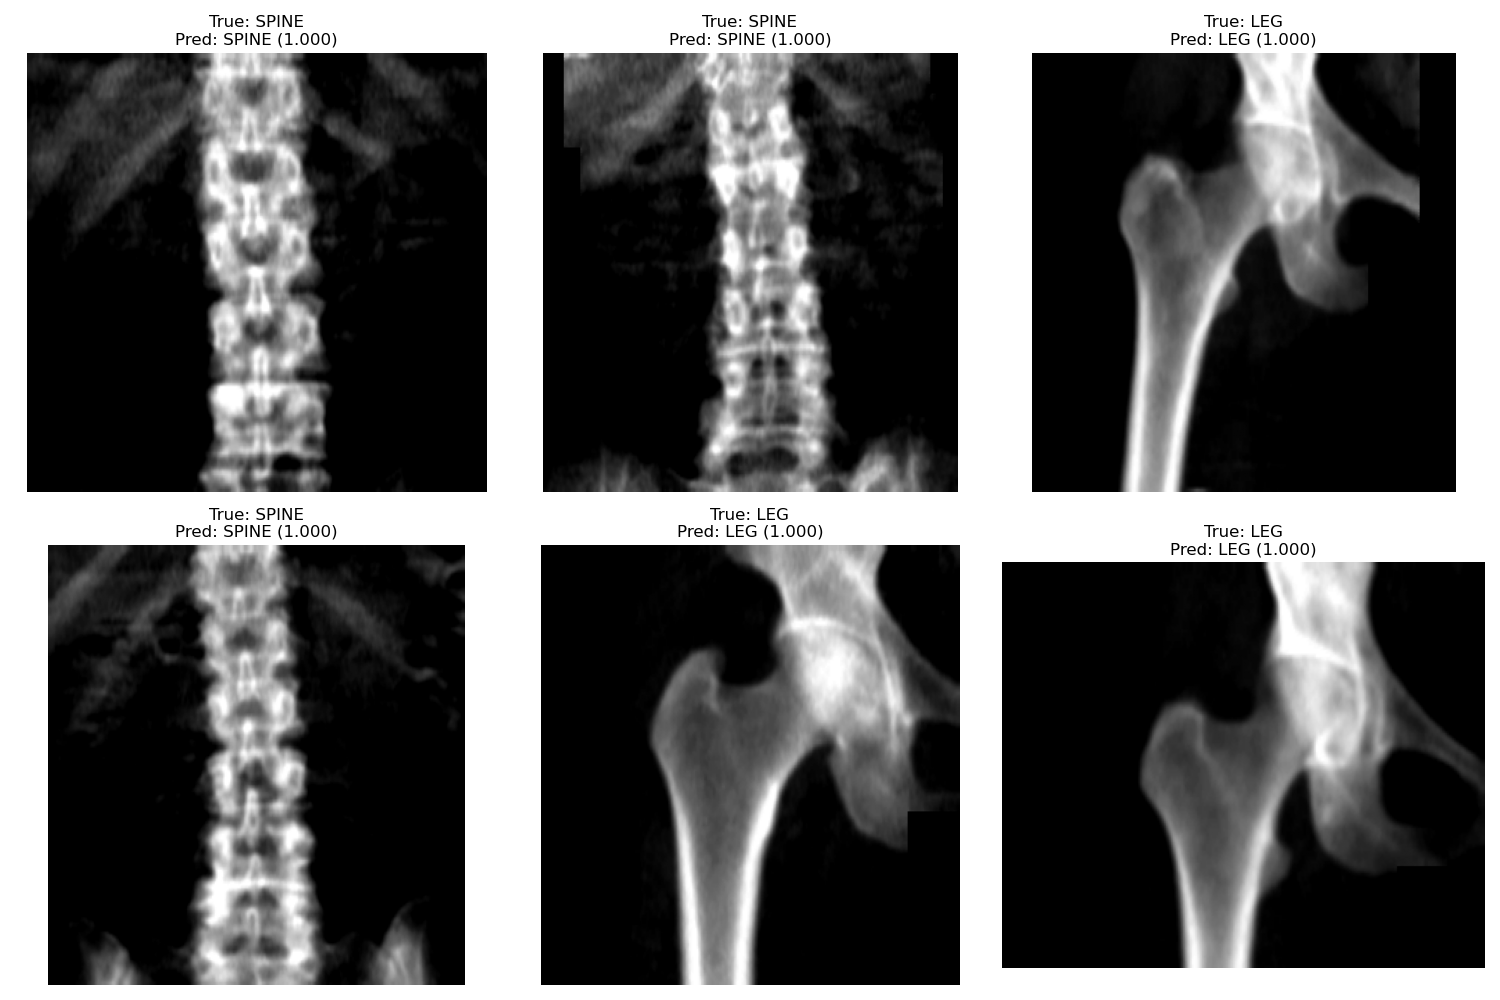

In [9]:
@torch.no_grad()
def show_classification_examples(
    model,
    frame,
    label_to_idx,
    n=6
):
    idx_to_label = {
        v: k
        for k, v
        in label_to_idx.items()
    }

    sample = frame.sample(
        min(n, len(frame)),
        random_state=SEED
    )

    cols = 3
    rows = math.ceil(
        len(sample) / cols
    )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 5 * rows)
    )

    axes = np.asarray(
        axes
    ).reshape(-1)

    for ax, (_, row) in zip(
        axes,
        sample.iterrows()
    ):
        pil = dicom_to_pil(
            row["dicom_path"]
        )

        x = eval_transform(
            pil
        ).unsqueeze(0).to(
            DEVICE
        )

        probs = torch.softmax(
            model(x),
            dim=1
        )[0].cpu().numpy()

        pred_idx = int(
            np.argmax(probs)
        )

        pred = idx_to_label[
            pred_idx
        ]

        _, _, _, img, _ = preprocess_dicom(
            row["dicom_path"]
        )

        ax.imshow(
            img,
            cmap="gray"
        )

        ax.set_title(
            f"True: {row['label']}\n"
            f"Pred: {pred} "
            f"({probs[pred_idx]:.3f})"
        )

        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


if spine_leg_model is not None:
    show_classification_examples(
        spine_leg_model,
        labels_df,
        spine_leg_label_to_idx,
        n=6,
    )

## 5. Бедро — металл

Создаётся отдельный `metal_labels.csv` для изображений `LEG`.

Формат: `relative_path, metal`, где `metal` = `0` или `1`.

После заполнения используется тот же ResNet-пайплайн.

In [10]:
if len(labels_df):
    leg_rows = labels_df[labels_df["label"] == "LEG"].copy()

    if not METAL_LABELS_CSV.exists():
        template = leg_rows[["relative_path"]].copy()
        template["metal"] = ""
        template.to_csv(METAL_LABELS_CSV, index=False, encoding="utf-8-sig")
        print("Создан шаблон:", METAL_LABELS_CSV)
    else:
        print("Файл уже существует:", METAL_LABELS_CSV)

Файл уже существует: C:\Users\Андрей\Desktop\Хакатон\metal_labels.csv


In [11]:
metal_model = None

if METAL_LABELS_CSV.exists():
    metal_df = pd.read_csv(
        METAL_LABELS_CSV,
        dtype=str
    ).fillna("")

    metal_df = metal_df[
        metal_df["metal"].isin(["0", "1"])
    ].copy()

    if len(metal_df):
        metal_df["label"] = metal_df[
            "metal"
        ].map({
            "0": "NO_METAL",
            "1": "METAL",
        })

        resolved = metal_df[
            "relative_path"
        ].map(resolve_dicom_path)

        metal_df["dicom_path"] = resolved.map(
            lambda x: x[0]
        )
        metal_df["resolve_method"] = resolved.map(
            lambda x: x[1]
        )

        missing_metal = metal_df[
            metal_df["dicom_path"].isna()
        ]

        print(
            "Не найдено DICOM для metal_labels:",
            len(missing_metal)
        )

        if len(missing_metal):
            display(
                missing_metal[
                    ["relative_path", "metal"]
                ].head(20)
            )

        metal_df = metal_df[
            metal_df["dicom_path"].notna()
        ].copy()

        display(
            metal_df["label"]
            .value_counts()
            .to_frame("count")
        )

        if (
            len(metal_df) >= 10
            and metal_df["label"].nunique() == 2
        ):
            metal_label_to_idx = {
                "NO_METAL": 0,
                "METAL": 1,
            }

            (
                metal_model,
                metal_history,
                metal_outputs
            ) = fit_classifier_all_data(
                metal_df,
                metal_label_to_idx
            )

            display(metal_history)

            y_true, y_pred, y_prob = (
                metal_outputs
            )

            print(
                classification_report(
                    y_true,
                    y_pred,
                    target_names=[
                        "NO_METAL",
                        "METAL"
                    ],
                    zero_division=0,
                )
            )

            print(
                confusion_matrix(
                    y_true,
                    y_pred
                )
            )

            torch.save(
                {
                    "state_dict":
                        metal_model.state_dict(),
                    "label_to_idx":
                        metal_label_to_idx,
                },
                WORK_DIR
                / "resnet18_metal.pt",
            )

            show_classification_examples(
                metal_model,
                metal_df,
                metal_label_to_idx,
                n=6,
            )

        else:
            print(
                "Пока мало заполненных 0/1 "
                "или присутствует только один класс."
            )

## 6. Бедро — грубая маска для геометрических проверок

Это не финальная сегментация. Маска нужна только для прототипа угловых эвристик.

In [12]:
def keep_reasonable_components(mask, min_fraction=0.002):
    labeled = cc_label(mask)
    out = np.zeros_like(mask, dtype=bool)
    min_area = int(mask.size * min_fraction)

    for region in regionprops(labeled):
        if region.area >= min_area:
            out[labeled == region.label] = True

    return out


def rough_bone_mask(img01):
    positive = img01[img01 > 0]

    if len(positive) == 0:
        return np.zeros_like(img01, dtype=bool)

    try:
        threshold = threshold_otsu(positive)
    except Exception:
        threshold = np.quantile(positive, 0.5)

    mask = img01 >= threshold
    mask = binary_closing(mask, disk(2))
    mask = remove_small_objects(mask, min_size=max(64, int(mask.size * 0.001)))
    mask = remove_small_holes(mask, area_threshold=max(64, int(mask.size * 0.001)))
    return keep_reasonable_components(mask)


def mask_bbox(mask, pad=5):
    ys, xs = np.where(mask)

    if len(xs) == 0:
        return 0, 0, mask.shape[1], mask.shape[0]

    return (
        max(0, xs.min() - pad),
        max(0, ys.min() - pad),
        min(mask.shape[1], xs.max() + pad + 1),
        min(mask.shape[0], ys.max() + pad + 1),
    )


def canonicalize_hip(img, mask):
    h, w = mask.shape
    lower = mask[int(h * 0.55):]
    col_counts = lower.sum(axis=0)

    if col_counts.max() == 0:
        return img, mask, False

    shaft_x = int(np.argmax(col_counts))
    do_flip = shaft_x < w / 2

    if do_flip:
        return np.fliplr(img), np.fliplr(mask), True

    return img, mask, False

## 7. Бедро — ручные точки и поиск самого узкого места

Новая логика:

1. На изображении **вручную кликаем три примерные точки** `1`, `2`, `3`.
2. Для каждой точки заранее задан угол линии **относительно вертикали**.
3. Вокруг выбранной точки перебираем параллельные линии, смещаясь перпендикулярно им.
4. Для каждой линии считаем **число ненулевых пикселей**.
5. Нулевые линии игнорируем.
6. Выбираем линию с минимальным ненулевым количеством пикселей — это кандидат на самое узкое место.
7. По значениям интенсивности на выбранной линии считаем центр масс и показываем его на изображении.

Bounding box для этих трёх точек больше не используется.

In [13]:
def select_points_on_image(
    path,
    labels=("1", "2", "3")
):
    """
    Интерактивный выбор точек.
    Требует %matplotlib widget / ipympl.

    Кликните точки по порядку, указанному в labels.
    """
    _, _, norm, _, _ = preprocess_dicom(path)

    fig, ax = plt.subplots(
        figsize=(8, 10)
    )

    ax.imshow(
        norm,
        cmap="gray"
    )

    ax.set_title(
        "Кликните точки по порядку: "
        + ", ".join(labels)
    )

    ax.axis("off")

    points = plt.ginput(
        n=len(labels),
        timeout=-1,
        show_clicks=True,
    )

    result = {}

    for label, point in zip(
        labels,
        points
    ):
        x, y = point
        result[str(label)] = (
            float(x),
            float(y)
        )

        ax.scatter(
            [x],
            [y],
            s=70,
        )

        ax.text(
            x + 5,
            y,
            str(label),
            fontsize=12,
        )

    fig.canvas.draw_idle()

    print("Выбранные точки:")
    print(result)

    return result


def line_direction_from_vertical(
    angle_deg
):
    """
    x направо, y вниз.
    angle=0 -> вертикально вниз.
    """
    theta = np.deg2rad(
        angle_deg
    )

    dx = np.sin(theta)
    dy = np.cos(theta)

    return np.array(
        [dx, dy],
        dtype=np.float32
    )


def sample_line_pixels(
    img,
    center_xy,
    angle_from_vertical,
    half_length
):
    h, w = img.shape

    direction = line_direction_from_vertical(
        angle_from_vertical
    )

    ts = np.arange(
        -half_length,
        half_length + 1,
        dtype=np.float32
    )

    xs = np.rint(
        center_xy[0]
        + ts * direction[0]
    ).astype(int)

    ys = np.rint(
        center_xy[1]
        + ts * direction[1]
    ).astype(int)

    valid = (
        (xs >= 0)
        & (xs < w)
        & (ys >= 0)
        & (ys < h)
    )

    xs = xs[valid]
    ys = ys[valid]
    ts = ts[valid]

    # После округления некоторые пиксели могут повторяться.
    coords = np.column_stack(
        [xs, ys]
    )

    if len(coords):
        _, unique_idx = np.unique(
            coords,
            axis=0,
            return_index=True
        )

        unique_idx = np.sort(
            unique_idx
        )

        xs = xs[unique_idx]
        ys = ys[unique_idx]
        ts = ts[unique_idx]

    values = img[
        ys,
        xs
    ]

    return {
        "xs": xs,
        "ys": ys,
        "ts": ts,
        "values": values,
        "direction": direction,
    }


def evaluate_parallel_line(
    img,
    seed_xy,
    angle_from_vertical,
    offset_px
):
    direction = line_direction_from_vertical(
        angle_from_vertical
    )

    # Перпендикуляр к основной линии.
    perp = np.array(
        [
            direction[1],
            -direction[0],
        ],
        dtype=np.float32
    )

    center = (
        np.asarray(
            seed_xy,
            dtype=np.float32
        )
        + offset_px * perp
    )

    line = sample_line_pixels(
        img=img,
        center_xy=center,
        angle_from_vertical=angle_from_vertical,
        half_length=HIP_LINE_HALF_LENGTH_PX,
    )

    values = line["values"]
    nonzero = values > 0
    width_px = int(
        nonzero.sum()
    )

    if (
        width_px
        < HIP_MIN_NONZERO_PIXELS
    ):
        return None

    nz_values = values[
        nonzero
    ]

    nz_ts = line["ts"][
        nonzero
    ]

    # Центр масс по интенсивности вдоль выбранной оси.
    if nz_values.sum() > 0:
        com_t = float(
            np.sum(
                nz_ts * nz_values
            )
            / np.sum(
                nz_values
            )
        )
    else:
        com_t = float(
            nz_ts.mean()
        )

    direction = line[
        "direction"
    ]

    com_xy = (
        center
        + com_t * direction
    )

    # Для визуализации показываем диапазон,
    # занятый ненулевыми пикселями.
    t_min = float(
        nz_ts.min()
    )
    t_max = float(
        nz_ts.max()
    )

    p1 = (
        center
        + t_min * direction
    )

    p2 = (
        center
        + t_max * direction
    )

    return {
        "offset_px": float(offset_px),
        "center_xy": center,
        "width_px": width_px,
        "com_xy": com_xy,
        "segment_p1": p1,
        "segment_p2": p2,
    }


def find_narrowest_parallel_line(
    img,
    seed_xy,
    angle_from_vertical
):
    records = []

    best = None

    for offset in range(
        -HIP_OFFSET_SEARCH_PX,
        HIP_OFFSET_SEARCH_PX + 1
    ):
        result = evaluate_parallel_line(
            img=img,
            seed_xy=seed_xy,
            angle_from_vertical=angle_from_vertical,
            offset_px=offset,
        )

        if result is None:
            continue

        records.append(
            {
                "offset_px":
                    result["offset_px"],
                "width_px":
                    result["width_px"],
            }
        )

        if (
            best is None
            or result["width_px"]
            < best["width_px"]
            or (
                result["width_px"]
                == best["width_px"]
                and abs(result["offset_px"])
                < abs(best["offset_px"])
            )
        ):
            best = result

    if best is None:
        return None

    best[
        "records"
    ] = pd.DataFrame(
        records
    )

    best[
        "angle_from_vertical"
    ] = float(
        angle_from_vertical
    )

    return best


def analyze_hip_manual_points(
    path,
    points
):
    """
    points:
    {
        "1": (x, y),
        "2": (x, y),
        "3": (x, y),
    }
    """
    _, _, norm, filtered, threshold = preprocess_dicom(
        path
    )

    results = {}

    for key in (
        "1",
        "2",
        "3"
    ):
        if key not in points:
            results[key] = None
            continue

        results[key] = (
            find_narrowest_parallel_line(
                img=filtered,
                seed_xy=points[key],
                angle_from_vertical=
                    HIP_LINE_ANGLES_FROM_VERTICAL[key],
            )
        )

    return (
        norm,
        filtered,
        threshold,
        results,
    )


def plot_hip_manual_points(
    path,
    points
):
    (
        norm,
        filtered,
        threshold,
        results
    ) = analyze_hip_manual_points(
        path,
        points
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 8)
    )

    axes[0].imshow(
        norm,
        cmap="gray"
    )

    axes[0].set_title(
        "Выбранные точки и "
        "найденные узкие места"
    )

    axes[0].axis("off")

    axes[1].set_title(
        "Ширина = число ненулевых пикселей"
    )

    axes[1].set_xlabel(
        "Смещение параллельной линии, px"
    )

    axes[1].set_ylabel(
        "Ненулевых пикселей на линии"
    )

    colors = {
        "1": "tab:red",
        "2": "tab:green",
        "3": "tab:blue",
    }

    summary = []

    for key in (
        "1",
        "2",
        "3"
    ):
        seed = points.get(
            key
        )

        if seed is not None:
            axes[0].scatter(
                [seed[0]],
                [seed[1]],
                s=80,
                marker="x",
                color=colors[key],
            )

            axes[0].text(
                seed[0] + 4,
                seed[1],
                f"seed {key}",
                color=colors[key],
                fontsize=10,
            )

        result = results[
            key
        ]

        if result is None:
            summary.append({
                "point": key,
                "status": "NOT_FOUND",
            })
            continue

        p1 = result[
            "segment_p1"
        ]

        p2 = result[
            "segment_p2"
        ]

        com = result[
            "com_xy"
        ]

        axes[0].plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            linewidth=3,
            color=colors[key],
            label=(
                f"{key}: "
                f"{result['width_px']} px, "
                f"{result['angle_from_vertical']:.0f}°"
            ),
        )

        axes[0].scatter(
            [com[0]],
            [com[1]],
            s=45,
            color=colors[key],
        )

        frame = result[
            "records"
        ]

        axes[1].plot(
            frame["offset_px"],
            frame["width_px"],
            color=colors[key],
            label=f"point {key}",
        )

        axes[1].scatter(
            [result["offset_px"]],
            [result["width_px"]],
            s=55,
            color=colors[key],
        )

        summary.append({
            "point": key,
            "angle_from_vertical":
                result["angle_from_vertical"],
            "best_offset_px":
                result["offset_px"],
            "width_nonzero_px":
                result["width_px"],
            "center_mass_x":
                result["com_xy"][0],
            "center_mass_y":
                result["com_xy"][1],
            "status": "OK",
        })

    axes[0].legend()
    axes[1].grid(
        alpha=0.25
    )
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(
        summary
    )

In [14]:
# ============================================================
# ИНТЕРАКТИВНЫЙ ПРИМЕР ДЛЯ ОДНОГО БЕДРА
# ============================================================
#
# 1. Выберите изображение.
# 2. Запустите select_points_on_image().
# 3. Кликните точки 1, 2, 3 по порядку.
# 4. После выбора запустится анализ ширины.

leg_examples = pd.DataFrame()

if len(labels_df):
    leg_pool = labels_df[
        labels_df["label"] == "LEG"
    ]

    if len(leg_pool):
        leg_examples = leg_pool.sample(
            min(3, len(leg_pool)),
            random_state=SEED
        )

        display(
            leg_examples[
                [
                    "relative_path",
                    "dicom_path"
                ]
            ]
        )


# Пример запуска:
#
# hip_path = leg_examples.iloc[0]["dicom_path"]
# hip_points = select_points_on_image(
#     hip_path,
#     labels=("1", "2", "3")
# )
# display(
#     plot_hip_manual_points(
#         hip_path,
#         hip_points
#     )
# )

,relative_path,dicom_path
38,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...
463,2.25.165091430504580219034019815337441064349/s...,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...
106,1.2.840.113619.2.110.512719.20250403090444/ser...,C:\Users\Андрей\Desktop\Хакатон\Исследования\2...


## 8. Бедро — ротация ("горбик") без порога

Для поиска горбика **не используем бинаризацию и не зануляем пиксели**.

Новая схема:

1. Работаем с нормализованным, но **не пороговым** изображением.
2. Пользователь кликает примерную точку горбика.
3. В локальном окне считаем горизонтальный градиент яркости.
4. По строкам трассируем наиболее сильную границу с ограничением на скачок координаты.
5. Сглаживаем найденную линию и ищем максимальный локальный turning angle.

Это позволяет анализировать форму границы без предварительного отсечения значений по порогу.

In [15]:
def trace_edge_from_gradient(
    img,
    seed_xy,
    half_width=BUMP_ROI_HALF_WIDTH,
    half_height=BUMP_ROI_HALF_HEIGHT,
    continuity_px=BUMP_EDGE_CONTINUITY_PX,
):
    """
    Трассировка края БЕЗ intensity threshold.

    Используем |dI/dx| и выбираем максимум градиента
    с ограничением непрерывности между соседними строками.
    """
    h, w = img.shape

    sx = int(round(seed_xy[0]))
    sy = int(round(seed_xy[1]))

    x0 = max(
        0,
        sx - half_width
    )
    x1 = min(
        w,
        sx + half_width + 1
    )

    y0 = max(
        0,
        sy - half_height
    )
    y1 = min(
        h,
        sy + half_height + 1
    )

    roi = img[
        y0:y1,
        x0:x1
    ].astype(
        np.float32
    )

    grad_x = np.abs(
        cv2.Sobel(
            roi,
            cv2.CV_32F,
            1,
            0,
            ksize=3
        )
    )

    local_seed_x = int(
        np.clip(
            sx - x0,
            0,
            roi.shape[1] - 1
        )
    )

    local_seed_y = int(
        np.clip(
            sy - y0,
            0,
            roi.shape[0] - 1
        )
    )

    edge_x = np.full(
        roi.shape[0],
        np.nan,
        dtype=np.float32
    )

    # В строке seed ищем сильный gradient
    # около вручную указанной точки.
    left = max(
        0,
        local_seed_x
        - continuity_px * 2
    )
    right = min(
        roi.shape[1],
        local_seed_x
        + continuity_px * 2
        + 1
    )

    start_x = (
        left
        + int(
            np.argmax(
                grad_x[
                    local_seed_y,
                    left:right
                ]
            )
        )
    )

    edge_x[
        local_seed_y
    ] = start_x

    # Вниз.
    prev_x = start_x

    for yy in range(
        local_seed_y + 1,
        roi.shape[0]
    ):
        left = max(
            0,
            int(prev_x)
            - continuity_px
        )
        right = min(
            roi.shape[1],
            int(prev_x)
            + continuity_px
            + 1
        )

        if right <= left:
            continue

        xx = (
            left
            + int(
                np.argmax(
                    grad_x[
                        yy,
                        left:right
                    ]
                )
            )
        )

        edge_x[yy] = xx
        prev_x = xx

    # Вверх.
    prev_x = start_x

    for yy in range(
        local_seed_y - 1,
        -1,
        -1
    ):
        left = max(
            0,
            int(prev_x)
            - continuity_px
        )
        right = min(
            roi.shape[1],
            int(prev_x)
            + continuity_px
            + 1
        )

        if right <= left:
            continue

        xx = (
            left
            + int(
                np.argmax(
                    grad_x[
                        yy,
                        left:right
                    ]
                )
            )
        )

        edge_x[yy] = xx
        prev_x = xx

    valid = np.isfinite(
        edge_x
    )

    ys_local = np.where(
        valid
    )[0]

    xs_local = edge_x[
        valid
    ]

    if len(xs_local) < 9:
        return None

    # Сглаживаем только координату x(y).
    win = min(
        31,
        len(xs_local)
    )

    if win % 2 == 0:
        win -= 1

    if win < 7:
        return None

    xs_smooth = savgol_filter(
        xs_local,
        window_length=win,
        polyorder=2,
        mode="interp",
    )

    points = np.column_stack([
        xs_smooth + x0,
        ys_local + y0,
    ]).astype(
        np.float32
    )

    return {
        "points": points,
        "roi": roi,
        "grad_x": grad_x,
        "roi_box": (
            x0,
            y0,
            x1,
            y1
        ),
    }


def turning_angles_open_curve(
    points,
    window=8
):
    angles = np.full(
        len(points),
        np.nan,
        dtype=np.float32
    )

    for i in range(
        window,
        len(points) - window
    ):
        p_prev = points[
            i - window
        ]

        p = points[i]

        p_next = points[
            i + window
        ]

        v1 = p - p_prev
        v2 = p_next - p

        n1 = np.linalg.norm(v1)
        n2 = np.linalg.norm(v2)

        if n1 == 0 or n2 == 0:
            continue

        v1 /= n1
        v2 /= n2

        cross = (
            v1[0] * v2[1]
            - v1[1] * v2[0]
        )

        dot = np.clip(
            np.dot(v1, v2),
            -1,
            1
        )

        angles[i] = np.rad2deg(
            np.arctan2(
                cross,
                dot
            )
        )

    return angles


def analyze_hip_bump(
    path,
    bump_point
):
    # ВАЖНО:
    # берём norm, НЕ filtered.
    _, _, norm, _, _ = preprocess_dicom(
        path
    )

    traced = trace_edge_from_gradient(
        norm,
        seed_xy=bump_point,
    )

    if traced is None:
        return None

    points = traced[
        "points"
    ]

    turning = turning_angles_open_curve(
        points,
        window=max(
            5,
            len(points) // 35
        ),
    )

    finite = np.where(
        np.isfinite(turning)
    )[0]

    if len(finite) == 0:
        return None

    best_idx = int(
        finite[
            np.argmax(
                np.abs(
                    turning[finite]
                )
            )
        ]
    )

    return {
        "image": norm,
        "points": points,
        "turning_angles": turning,
        "best_idx": best_idx,
        "turning_angle":
            float(turning[best_idx]),
        **traced,
    }


def plot_hip_bump(
    path,
    bump_point
):
    result = analyze_hip_bump(
        path,
        bump_point
    )

    if result is None:
        print(
            "Не удалось устойчиво "
            "протрассировать границу."
        )
        return None

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 7)
    )

    axes[0].imshow(
        result["image"],
        cmap="gray"
    )

    points = result[
        "points"
    ]

    axes[0].plot(
        points[:, 0],
        points[:, 1],
        linewidth=2,
    )

    axes[0].scatter(
        [bump_point[0]],
        [bump_point[1]],
        marker="x",
        s=80,
    )

    p = points[
        result["best_idx"]
    ]

    axes[0].scatter(
        [p[0]],
        [p[1]],
        s=80,
    )

    axes[0].set_title(
        "Граница без порога\n"
        f"max turning angle = "
        f"{result['turning_angle']:.1f}°"
    )

    axes[0].axis("off")

    axes[1].plot(
        result[
            "turning_angles"
        ]
    )

    axes[1].axvline(
        result[
            "best_idx"
        ],
        linestyle="--",
    )

    axes[1].set_title(
        "Локальный угол поворота "
        "вдоль границы"
    )

    axes[1].set_xlabel(
        "Индекс точки границы"
    )

    axes[1].set_ylabel(
        "Turning angle, °"
    )

    axes[1].grid(
        alpha=0.25
    )

    plt.tight_layout()
    plt.show()

    return result


# Интерактивный пример:
#
# bump_path = leg_examples.iloc[0]["dicom_path"]
# bump_point = select_points_on_image(
#     bump_path,
#     labels=("bump",)
# )["bump"]
#
# _ = plot_hip_bump(
#     bump_path,
#     bump_point
# )

## 9. Позвоночник — профиль яркости и межпозвонковые линии

Сначала строим вертикальный профиль яркости, ищем тёмные локальные минимумы, затем для каждого кандидата перебираем угол линии и выбираем минимальную среднюю яркость вдоль линии.

In [16]:
def crop_spine_analysis_roi(
    img,
    x_range=(0.20, 0.80),
    y_range=(0.05, 0.95)
):
    h, w = img.shape

    x0 = int(
        w * x_range[0]
    )
    x1 = int(
        w * x_range[1]
    )

    y0 = int(
        h * y_range[0]
    )
    y1 = int(
        h * y_range[1]
    )

    return (
        img[
            y0:y1,
            x0:x1
        ],
        (
            x0,
            y0,
            x1,
            y1
        )
    )


def vertical_brightness_profile(
    img
):
    profile = img.mean(
        axis=1
    )

    smooth = gaussian_filter1d(
        profile,
        sigma=max(
            1.0,
            len(profile) / 250
        )
    )

    return (
        profile,
        smooth
    )


def choose_prominent_spaced_minima(
    profile_smooth,
    n_separators=6
):
    """
    1. Находим ВСЕ локальные минимумы профиля.
    2. Для каждого берём prominence.
    3. Сортируем по prominence: сначала самые выраженные.
    4. Greedy-отбор: новый минимум принимается только если
       он находится минимум на H/8 от уже выбранных.
    5. Берём максимум n_separators = 6.
    """
    profile_smooth = np.asarray(
        profile_smooth,
        dtype=np.float32
    )

    h = len(
        profile_smooth
    )

    min_distance = int(
        math.ceil(
            h
            / SPINE_MIN_DISTANCE_DIVISOR
        )
    )

    # Находим локальные минимумы как пики у -profile.
    peaks, props = find_peaks(
        -profile_smooth,
        prominence=0,
    )

    if len(peaks) == 0:
        return (
            np.array(
                [],
                dtype=int
            ),
            pd.DataFrame(),
            min_distance,
        )

    margin = int(
        h
        * SPINE_EDGE_MARGIN_FRAC
    )

    valid = (
        (peaks >= margin)
        & (peaks < h - margin)
    )

    peaks = peaks[
        valid
    ]

    prominences = props[
        "prominences"
    ][
        valid
    ]

    if len(peaks) == 0:
        return (
            np.array(
                [],
                dtype=int
            ),
            pd.DataFrame(),
            min_distance,
        )

    candidates = pd.DataFrame({
        "y":
            peaks.astype(int),

        "brightness":
            profile_smooth[peaks],

        "prominence":
            prominences.astype(float),
    })

    # Ключевой момент:
    # сортировка ПО ВЫРАЖЕННОСТИ,
    # а не просто по абсолютной яркости.
    ranked = candidates.sort_values(
        [
            "prominence",
            "brightness"
        ],
        ascending=[
            False,
            True
        ],
    ).reset_index(
        drop=True
    )

    selected = []

    for row in ranked.itertuples(
        index=False
    ):
        y = int(
            row.y
        )

        if all(
            abs(y - yy)
            >= min_distance
            for yy in selected
        ):
            selected.append(
                y
            )

        if (
            len(selected)
            == n_separators
        ):
            break

    selected = np.array(
        sorted(selected),
        dtype=int
    )

    candidates[
        "selected"
    ] = candidates[
        "y"
    ].isin(
        set(
            selected.tolist()
        )
    )

    candidates[
        "min_required_distance"
    ] = min_distance

    return (
        selected,
        candidates.sort_values(
            "y"
        ).reset_index(
            drop=True
        ),
        min_distance,
    )


def sample_line_mean(
    img,
    y0,
    angle_deg,
    x_margin=0.08
):
    h, w = img.shape

    xs = np.arange(
        int(
            w * x_margin
        ),
        int(
            w
            * (1 - x_margin)
        )
    )

    slope = math.tan(
        math.radians(
            angle_deg
        )
    )

    ys = (
        y0
        + slope
        * (
            xs
            - w / 2
        )
    )

    ys = np.round(
        ys
    ).astype(
        int
    )

    valid = (
        (ys >= 0)
        & (ys < h)
    )

    if (
        valid.sum()
        < max(
            5,
            len(xs) * 0.5
        )
    ):
        return np.inf

    return float(
        img[
            ys[valid],
            xs[valid]
        ].mean()
    )


def optimize_separator_angle(
    img,
    y_candidate
):
    """
    Y уже найден как локальный выраженный антипик.
    Чтобы не нарушить H/8, Y НЕ двигаем.
    Перебираем только угол линии.
    """
    records = []

    for angle in np.arange(
        SPINE_SEPARATOR_ANGLE_RANGE[0],
        SPINE_SEPARATOR_ANGLE_RANGE[1]
        + 1e-9,
        SPINE_SEPARATOR_ANGLE_STEP,
    ):
        records.append({
            "y":
                int(y_candidate),

            "angle":
                float(angle),

            "mean_intensity":
                sample_line_mean(
                    img,
                    y_candidate,
                    angle
                ),
        })

    frame = pd.DataFrame(
        records
    )

    best = frame.loc[
        frame[
            "mean_intensity"
        ].idxmin()
    ]

    return {
        "y":
            float(y_candidate),

        "angle":
            float(
                best[
                    "angle"
                ]
            ),

        "score":
            float(
                best[
                    "mean_intensity"
                ]
            ),

        "records":
            frame,
    }


def analyze_spine_separators(
    path
):
    _, _, _, img, _ = preprocess_dicom(
        path
    )

    roi, roi_box = crop_spine_analysis_roi(
        img
    )

    _, profile = vertical_brightness_profile(
        roi
    )

    (
        candidate_ys,
        candidate_table,
        min_distance
    ) = choose_prominent_spaced_minima(
        profile,
        n_separators=SPINE_N_SEPARATORS,
    )

    separators = [
        optimize_separator_angle(
            roi,
            y
        )
        for y
        in candidate_ys
    ]

    separators = sorted(
        separators,
        key=lambda x: x["y"]
    )

    return (
        img,
        roi,
        roi_box,
        profile,
        candidate_table,
        separators,
        min_distance,
    )


def plot_spine_separators(
    path
):
    (
        img,
        roi,
        roi_box,
        profile,
        candidate_table,
        separators,
        min_distance
    ) = analyze_spine_separators(
        path
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 7)
    )

    axes[0].imshow(
        img,
        cmap="gray"
    )

    (
        x0,
        y0,
        x1,
        y1
    ) = roi_box

    axes[0].add_patch(
        plt.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            fill=False,
            linewidth=1.3
        )
    )

    axes[0].set_title(
        "ROI позвоночника"
    )

    axes[0].axis(
        "off"
    )

    axes[1].plot(
        profile,
        np.arange(
            len(profile)
        )
    )

    axes[1].invert_yaxis()

    axes[1].set_title(
        "Вертикальный профиль яркости\n"
        f"min distance = {min_distance} px "
        f"(H/{SPINE_MIN_DISTANCE_DIVISOR})"
    )

    axes[1].set_xlabel(
        "Средняя яркость"
    )

    # Все кандидаты серым.
    if not candidate_table.empty:
        not_selected = candidate_table[
            ~candidate_table[
                "selected"
            ]
        ]

        axes[1].scatter(
            not_selected[
                "brightness"
            ],
            not_selected[
                "y"
            ],
            s=18,
            alpha=0.35,
            color="gray",
            label="локальные минимумы"
        )

        selected_table = candidate_table[
            candidate_table[
                "selected"
            ]
        ]

        axes[1].scatter(
            selected_table[
                "brightness"
            ],
            selected_table[
                "y"
            ],
            s=65,
            color="red",
            label="6 наиболее выраженных"
        )

        axes[1].legend()

    axes[2].imshow(
        roi,
        cmap="gray"
    )

    w = roi.shape[1]

    for i, sep in enumerate(
        separators,
        start=1
    ):
        xs = np.array(
            [
                0,
                w - 1
            ]
        )

        ys = (
            sep["y"]
            + np.tan(
                np.deg2rad(
                    sep["angle"]
                )
            )
            * (
                xs
                - w / 2
            )
        )

        axes[2].plot(
            xs,
            ys,
            linewidth=1.7
        )

        axes[2].text(
            w - 5,
            sep["y"],
            f"{i}",
            ha="right",
            va="center",
            fontsize=9,
            color="white",
        )

    axes[2].set_title(
        f"Границы: {len(separators)} / "
        f"{SPINE_N_SEPARATORS}"
    )

    axes[2].axis(
        "off"
    )

    plt.tight_layout()
    plt.show()

    return (
        separators,
        candidate_table,
        min_distance,
    )


2.25.156375884487675936513403083218009333856/series_003_2_CR/A250727121 DXA/CR DXA/CR000003.dcm


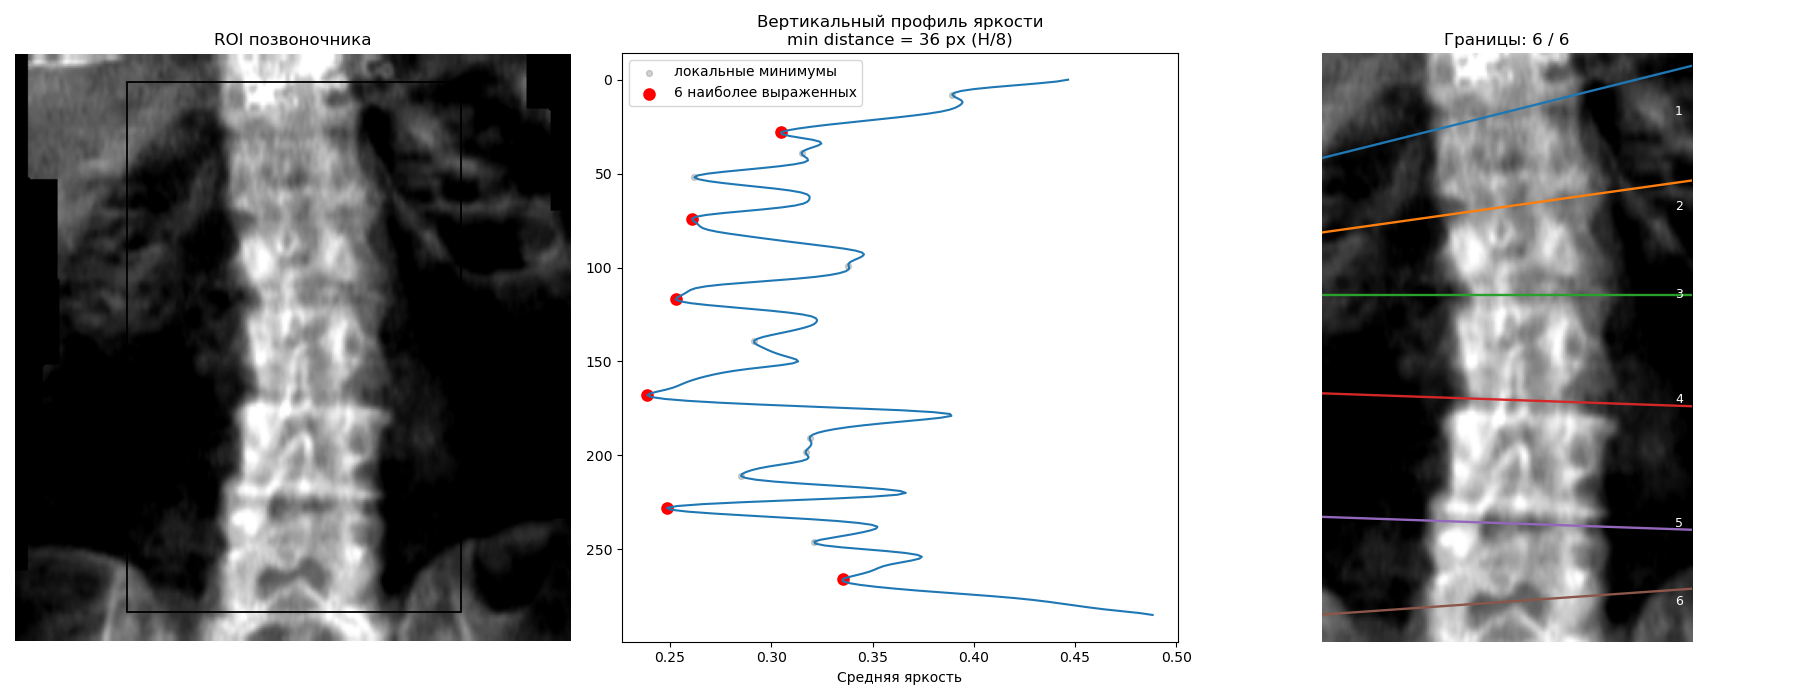

Найдено разделений: 6 (ожидается 6)
Минимальное расстояние между границами: 36 px


,separator_idx,y,angle,darkness_score
0,1,28.0,-14.0,0.286178
1,2,74.0,-8.0,0.287774
2,3,117.0,0.0,0.284476
3,4,168.0,2.0,0.277720
4,5,228.0,2.0,0.285513
5,6,266.0,-4.0,0.349025


,y,brightness,prominence,selected,min_required_distance
8,168,0.238833,0.207717,True,36
12,228,0.248523,0.140421,True,36
4,74,0.260856,0.084922,True,36
11,211,0.285095,0.081343,False,36
6,117,0.252853,0.069770,True,36
3,52,0.262041,0.056927,False,36
14,266,0.335222,0.039126,True,36
13,246,0.321230,0.031203,False,36
7,139,0.291562,0.021692,False,36
1,28,0.304862,0.019878,True,36



2.25.132083163398091874662674590622589534350/series_003_2_CR/A2507386583 DXA Exam/CR DXA Images/CR000001.dcm


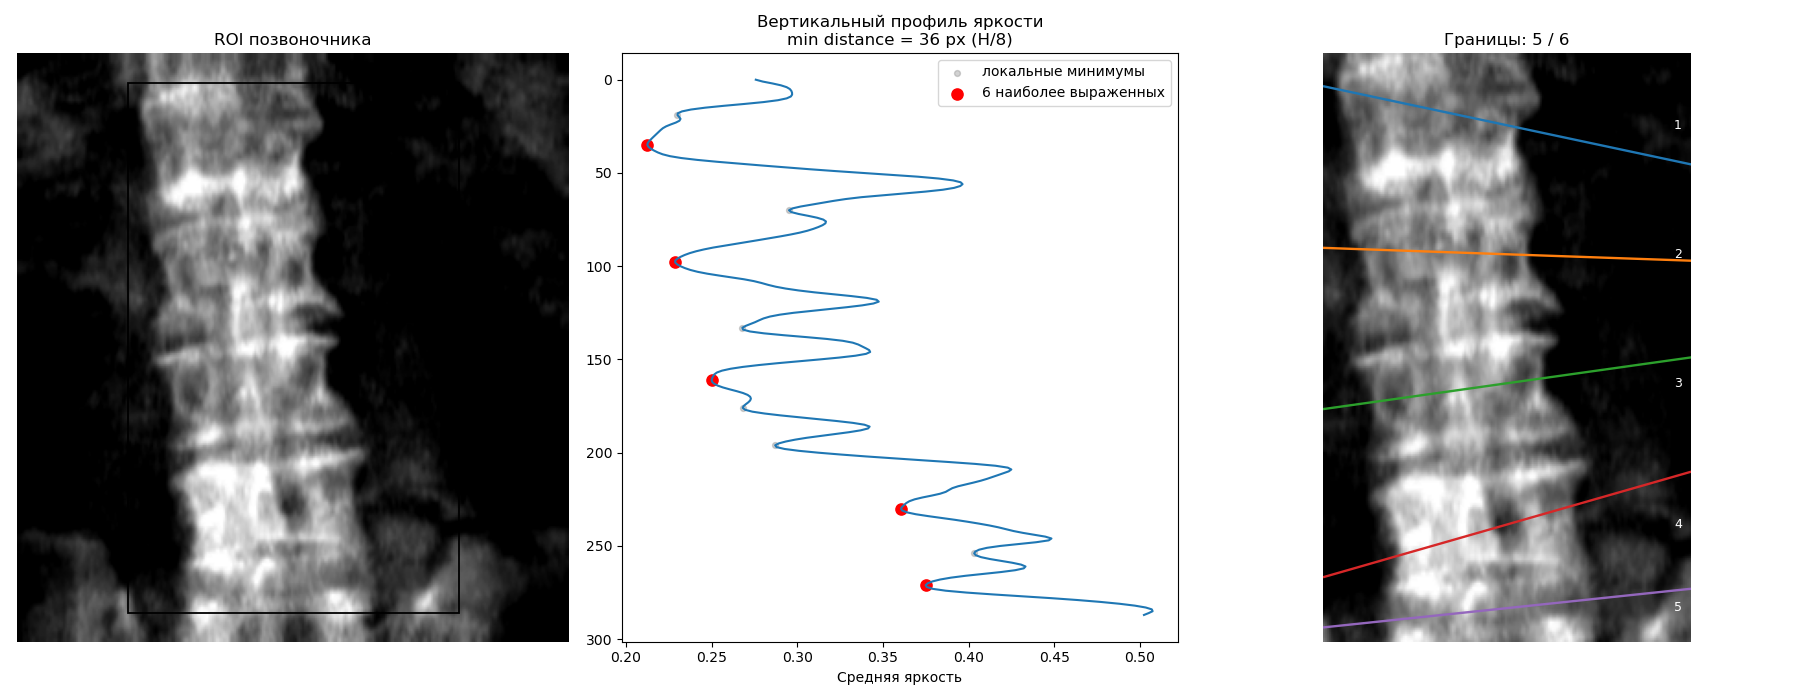

Найдено разделений: 5 (ожидается 6)
Минимальное расстояние между границами: 36 px


,separator_idx,y,angle,darkness_score
0,1,35.0,12.0,0.240749
1,2,98.0,2.0,0.261458
2,3,161.0,-8.0,0.282140
3,4,230.0,-16.0,0.411621
4,5,271.0,-6.0,0.389231


,y,brightness,prominence,selected,min_required_distance
3,98,0.228688,0.167777,True,36
5,161,0.249976,0.097538,True,36
1,35,0.212434,0.084498,True,36
4,133,0.267872,0.074649,False,36
10,271,0.374909,0.073442,True,36
8,230,0.360545,0.064377,True,36
7,196,0.287024,0.055164,False,36
9,254,0.403225,0.029975,False,36
2,70,0.295119,0.021571,False,36
6,176,0.268125,0.004752,False,36



2.25.151186844055172005615813066162721550889/series_002_2_CR/A250436130 DXA/CR DXA/CR000000.dcm


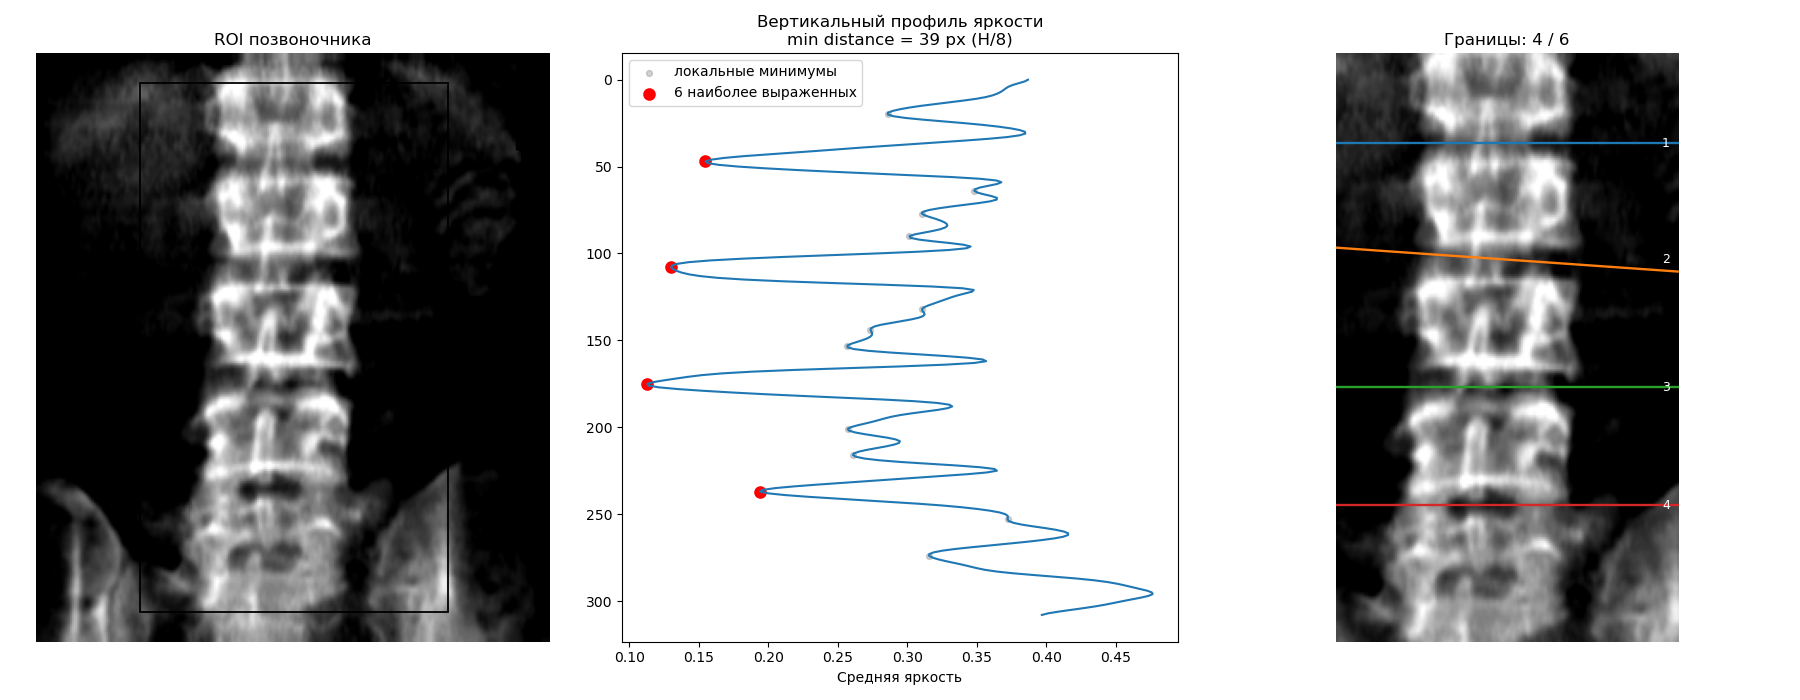

Найдено разделений: 4 (ожидается 6)
Минимальное расстояние между границами: 39 px


,separator_idx,y,angle,darkness_score
0,1,47.0,0.0,0.166201
1,2,108.0,4.0,0.143142
2,3,175.0,0.0,0.128647
3,4,237.0,0.0,0.200537


,y,brightness,prominence,selected,min_required_distance
9,175,0.112968,0.273845,True,39
5,108,0.130153,0.226540,True,39
1,47,0.154785,0.212892,True,39
12,237,0.194114,0.170327,True,39
14,274,0.315714,0.099995,False,39
0,20,0.285904,0.098978,False,39
8,153,0.256856,0.090956,False,39
10,201,0.257091,0.075228,False,39
4,90,0.301563,0.043992,False,39
11,216,0.260861,0.033783,False,39


In [17]:
spine_examples = pd.DataFrame()

if len(labels_df):
    spine_pool = labels_df[
        labels_df["label"] == "SPINE"
    ]

    if len(spine_pool):
        spine_examples = spine_pool.sample(
            min(
                3,
                len(spine_pool)
            ),
            random_state=SEED
        )

        for _, row in spine_examples.iterrows():
            print(
                "\n",
                "=" * 100
            )

            print(
                row[
                    "relative_path"
                ]
            )

            (
                separators,
                candidate_table,
                min_distance
            ) = plot_spine_separators(
                row[
                    "dicom_path"
                ]
            )

            print(
                f"Найдено разделений: "
                f"{len(separators)} "
                f"(ожидается "
                f"{SPINE_N_SEPARATORS})"
            )

            print(
                f"Минимальное расстояние "
                f"между границами: "
                f"{min_distance} px"
            )

            display(
                pd.DataFrame([
                    {
                        "separator_idx":
                            i + 1,

                        "y":
                            s["y"],

                        "angle":
                            s["angle"],

                        "darkness_score":
                            s["score"],
                    }
                    for i, s
                    in enumerate(
                        separators
                    )
                ])
            )

            if not candidate_table.empty:
                display(
                    candidate_table.sort_values(
                        "prominence",
                        ascending=False
                    )
                )

## 10. Позвоночник — оси симметрии

Сначала находим **6 межпозвонковых разделений**, которые делят ROI на **7 сегментов**:
`T12`, `L1`, `L2`, `L3`, `L4`, `L5`, `крестец`.

Затем для каждого сегмента отдельно ищем ось зеркальной симметрии.

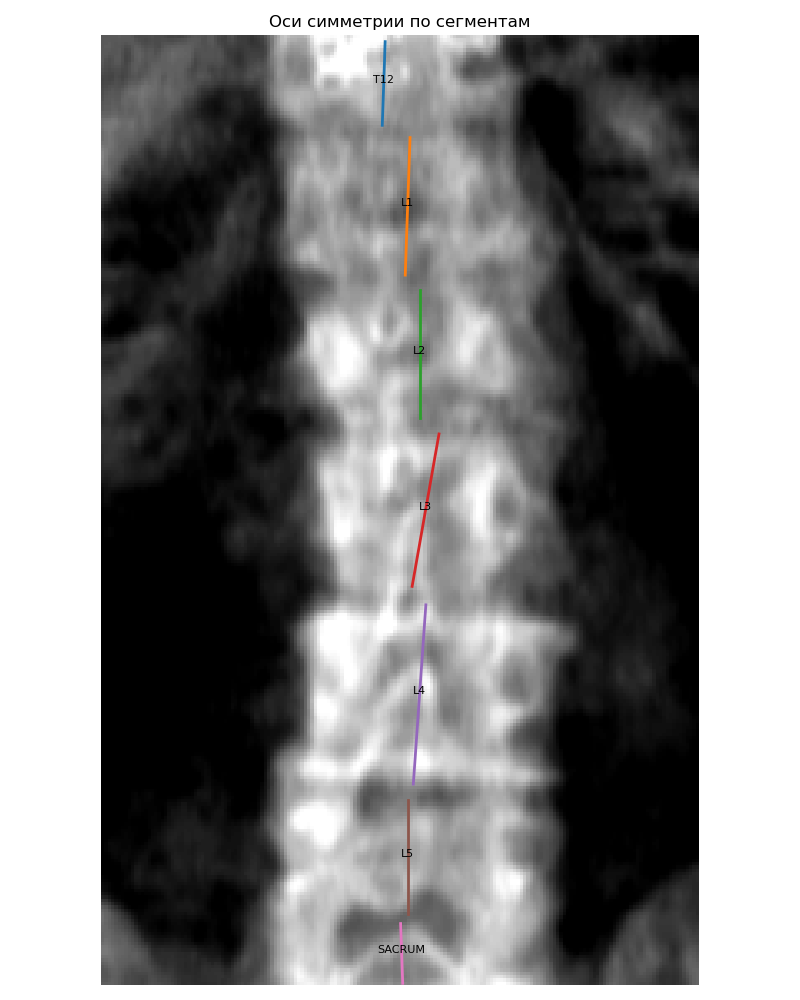

,segment_index,segment_name,y_top,y_bottom,y_center,x_center,vertical_angle,symmetry_error
0,0,T12,0,28,14.0,84.6,-2.0,0.143694
1,1,L1,28,74,51.0,91.8,-2.0,0.093984
2,2,L2,74,117,95.5,95.4,0.0,0.103980
3,3,L3,117,168,142.5,97.2,-10.0,0.088753
4,4,L4,168,228,198.0,95.4,-4.0,0.092502
5,5,L5,228,266,247.0,91.8,0.0,0.090940
6,6,SACRUM,266,286,276.0,90.0,2.0,0.078291


In [18]:
def symmetry_error_about_x(strip, x_center):
    h, w = strip.shape
    x_center = int(round(x_center))

    radius = min(x_center, w - x_center - 1)

    if radius < 5:
        return np.inf

    left = strip[:, x_center - radius:x_center]
    right = strip[:, x_center + 1:x_center + 1 + radius]

    radius = min(left.shape[1], right.shape[1])
    left = left[:, -radius:]
    right = right[:, :radius]

    return float(np.mean(np.abs(left - np.fliplr(right))))


def find_strip_symmetry(strip, angle_candidates=np.arange(-12, 13, 2)):
    best = None

    for angle in angle_candidates:
        rotated = ndi_rotate(
            strip,
            angle=-angle,
            reshape=False,
            order=1,
            mode="nearest",
        )

        w = rotated.shape[1]

        for x_center in np.linspace(w * 0.35, w * 0.65, 31):
            score = symmetry_error_about_x(rotated, x_center)

            candidate = {
                "vertical_angle": float(angle),
                "x_center": float(x_center),
                "score": score,
            }

            if best is None or score < best["score"]:
                best = candidate

    return best


def build_vertebra_symmetry_table(roi, separators):
    rows = []
    ys = sorted(int(round(s["y"])) for s in separators)

    boundaries = [0] + ys + [roi.shape[0]]

    for i, (y_top, y_bottom) in enumerate(zip(boundaries[:-1], boundaries[1:])):
        if y_bottom - y_top < 8:
            continue

        strip = roi[y_top:y_bottom]
        result = find_strip_symmetry(strip)

        if result is None:
            continue

        segment_name = (
            SPINE_SEGMENT_NAMES[i]
            if i < len(SPINE_SEGMENT_NAMES)
            else f"segment_{i}"
        )

        rows.append({
            "segment_index": i,
            "segment_name": segment_name,
            "y_top": y_top,
            "y_bottom": y_bottom,
            "y_center": (y_top + y_bottom) / 2,
            "x_center": result["x_center"],
            "vertical_angle": result["vertical_angle"],
            "symmetry_error": result["score"],
        })

    return pd.DataFrame(rows)


def plot_spine_symmetry(path):
    _, roi, _, _, _, separators, _ = analyze_spine_separators(path)
    table = build_vertebra_symmetry_table(roi, separators)

    fig, ax = plt.subplots(figsize=(8, 10))
    ax.imshow(roi, cmap="gray")

    for _, row in table.iterrows():
        yc = row["y_center"]
        xc = row["x_center"]
        half = max(5, (row["y_bottom"] - row["y_top"]) * 0.45)
        dx = math.tan(math.radians(row["vertical_angle"])) * half

        ax.plot(
            [xc - dx, xc + dx],
            [yc - half, yc + half],
            linewidth=2,
        )
        ax.text(
            xc,
            yc,
            str(row["segment_name"]),
            fontsize=8,
            ha="center",
        )

    ax.set_title("Оси симметрии по сегментам")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    return table


symmetry_table = pd.DataFrame()

if len(spine_examples):
    example = spine_examples.iloc[0]
    symmetry_table = plot_spine_symmetry(example["dicom_path"])
    display(symmetry_table)

### Верхний и нижний ориентиры

В текущей постановке рассматриваем 7 сегментов:
`T12`, `L1`, `L2`, `L3`, `L4`, `L5`, `SACRUM`.

Ниже можно посчитать:
- сумму локальных углов симметрии;
- подписанную сумму углов;
- угол линии между верхним и нижним ориентиром, например `T12` и `SACRUM`.

In [19]:
def angle_from_vertical(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    return float(np.rad2deg(np.arctan2(x2 - x1, y2 - y1)))


UPPER_SEGMENT_NAME = "T12"
LOWER_SEGMENT_NAME = "SACRUM"

if len(symmetry_table):
    print(
        "Сумма |углов симметрии|:",
        symmetry_table["vertical_angle"].abs().sum()
    )
    print(
        "Подписанная сумма:",
        symmetry_table["vertical_angle"].sum()
    )

    present_names = set(symmetry_table["segment_name"])

    if (
        UPPER_SEGMENT_NAME in present_names
        and LOWER_SEGMENT_NAME in present_names
    ):
        a = symmetry_table.loc[
            symmetry_table["segment_name"] == UPPER_SEGMENT_NAME
        ].iloc[0]
        b = symmetry_table.loc[
            symmetry_table["segment_name"] == LOWER_SEGMENT_NAME
        ].iloc[0]

        angle = angle_from_vertical(
            (a["x_center"], a["y_center"]),
            (b["x_center"], b["y_center"]),
        )

        print(
            f"Угол линии {UPPER_SEGMENT_NAME} → "
            f"{LOWER_SEGMENT_NAME} относительно вертикали:",
            angle
        )

Сумма |углов симметрии|: 20.0
Подписанная сумма: -16.0
Угол линии T12 → SACRUM относительно вертикали: 1.1807382055176345


## 11. Позвоночник — позиция: сегментация подвздошных костей

Для обучения нужны отдельные маски.

Ожидаемый `iliac_masks.csv`:

```csv
relative_path,mask_path
2.25.../CR000000.dcm,C:/.../mask_000000.png
```

Маска: `0` — фон, `255` — подвздошные кости.

Используем U-Net с ImageNet-pretrained ResNet34 encoder. После инференса считаем `mask.mean()` — долю площади подвздошных костей.

In [20]:
try:
    import segmentation_models_pytorch as smp
except ImportError:
    smp = None

SEG_SIZE = 256
SEG_BATCH_SIZE = 4
SEG_EPOCHS = 8


class IliacSegmentationDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]

        image = dicom_to_pil(row["dicom_path"]).resize((SEG_SIZE, SEG_SIZE))
        mask = Image.open(row["mask_path"]).convert("L").resize(
            (SEG_SIZE, SEG_SIZE),
            resample=Image.Resampling.NEAREST,
        )

        image = T.ToTensor()(image)
        image = T.Normalize(IMAGENET_MEAN, IMAGENET_STD)(image)

        mask = np.asarray(mask, dtype=np.float32) / 255.0
        mask = torch.from_numpy((mask > 0.5).astype(np.float32)).unsqueeze(0)

        return image, mask


def dice_loss_from_logits(logits, target, eps=1e-6):
    probs = torch.sigmoid(logits)
    intersection = (probs * target).sum(dim=(1, 2, 3))
    union = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def segmentation_loss(logits, target):
    bce = nn.functional.binary_cross_entropy_with_logits(logits, target)
    return bce + dice_loss_from_logits(logits, target)


def train_segmentation_model(train_frame, val_frame):
    if smp is None:
        raise RuntimeError("segmentation_models_pytorch не установлен")

    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
    ).to(DEVICE)

    train_loader = DataLoader(
        IliacSegmentationDataset(train_frame),
        batch_size=SEG_BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )
    val_loader = DataLoader(
        IliacSegmentationDataset(val_frame),
        batch_size=SEG_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=2e-4, weight_decay=1e-4
    )

    history = []

    for epoch in range(SEG_EPOCHS):
        model.train()
        train_losses = []

        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            logits = model(x)
            loss = segmentation_loss(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                val_losses.append(
                    segmentation_loss(model(x), y).item()
                )

        row = {
            "epoch": epoch + 1,
            "train_loss": float(np.mean(train_losses)),
            "val_loss": float(np.mean(val_losses)),
        }
        history.append(row)
        print(row)

    return model, pd.DataFrame(history)

In [21]:
iliac_model = None
iliac_val = pd.DataFrame()

if ILIAC_MASKS_CSV.exists():
    iliac_df = pd.read_csv(ILIAC_MASKS_CSV, dtype=str).fillna("")

    required = {"relative_path", "mask_path"}
    if not required.issubset(iliac_df.columns):
        raise ValueError("Нужны columns: relative_path, mask_path")

    iliac_df["dicom_path"] = iliac_df["relative_path"].map(
        relative_to_local_path
    )
    iliac_df = iliac_df[
        iliac_df["dicom_path"].map(Path.exists)
        & iliac_df["mask_path"].map(lambda p: Path(p).exists())
    ].copy()

    iliac_df["study_id"] = iliac_df["relative_path"].map(
        lambda x: normalize_relative_path(x).parts[0]
    )

    if len(iliac_df) >= 8:
        splitter = GroupShuffleSplit(
            n_splits=1, test_size=0.2, random_state=SEED
        )
        tr_idx, va_idx = next(
            splitter.split(iliac_df, groups=iliac_df["study_id"])
        )

        iliac_train = iliac_df.iloc[tr_idx].reset_index(drop=True)
        iliac_val = iliac_df.iloc[va_idx].reset_index(drop=True)

        iliac_model, iliac_history = train_segmentation_model(
            iliac_train, iliac_val
        )
        display(iliac_history)

        torch.save(
            iliac_model.state_dict(),
            WORK_DIR / "unet_iliac_bones.pt",
        )
    else:
        print("Недостаточно размеченных масок.")
else:
    print("iliac_masks.csv пока отсутствует — этот раздел пропускается.")

iliac_masks.csv пока отсутствует — этот раздел пропускается.


In [22]:
@torch.no_grad()
def predict_iliac_mask(model, dicom_path, threshold=0.5):
    pil = dicom_to_pil(dicom_path).resize((SEG_SIZE, SEG_SIZE))

    x = T.ToTensor()(pil)
    x = T.Normalize(IMAGENET_MEAN, IMAGENET_STD)(x)
    x = x.unsqueeze(0).to(DEVICE)

    prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
    mask = prob >= threshold
    area_fraction = float(mask.mean())

    return np.asarray(pil), prob, mask, area_fraction


def show_iliac_prediction(model, dicom_path):
    img, prob, mask, area_fraction = predict_iliac_mask(
        model, dicom_path
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("DXA")
    axes[0].axis("off")

    axes[1].imshow(prob, cmap="gray")
    axes[1].set_title("P(iliac bone)")
    axes[1].axis("off")

    axes[2].imshow(img, cmap="gray")
    axes[2].imshow(mask, alpha=0.35)
    axes[2].set_title(f"Area fraction={area_fraction:.3f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return area_fraction


if iliac_model is not None:
    results = []

    for _, row in iliac_val.head(5).iterrows():
        fraction = show_iliac_prediction(
            iliac_model, row["dicom_path"]
        )
        results.append({
            "relative_path": row["relative_path"],
            "iliac_area_fraction": fraction,
        })

    display(pd.DataFrame(results))

## 12. Что проверять в этой версии

1. **labels.csv**
   - сколько DICOM реально найдено в `STUDIES_ROOT`;
   - сколько путей разрешилось через `exact / unique_suffix / unique_basename`;
   - какие пути всё ещё `not_found`.

2. **Классификаторы**
   - `LEG / SPINE` и `NO_METAL / METAL` теперь обучаются на всех доступных данных;
   - метрики считаются на тех же данных и поэтому являются `in-sample`.

3. **Бедро**
   - вручную выберите точки `1`, `2`, `3`;
   - проверьте, что сканирование параллельных линий действительно находит ожидаемые узкие места;
   - ширина сейчас буквально равна числу ненулевых пикселей вдоль линии.

4. **Горбик**
   - выберите примерную точку горбика;
   - анализ работает по градиенту исходного нормализованного изображения, без threshold.

5. **Позвоночник**
   - выбираются наиболее выраженные локальные антипики по `prominence`;
   - между выбранными границами требуется расстояние не меньше `H/8`;
   - максимум выбирается 6 границ для 7 сегментов.